In [116]:
from sklearn.datasets import make_classification
import numpy as  np
import matplotlib.pyplot as plt
x,y=make_classification(n_samples=100,n_features=2,n_informative=1,class_sep=20,hypercube=False,
                        n_classes=2,n_clusters_per_class=1,n_redundant=0,random_state=41)

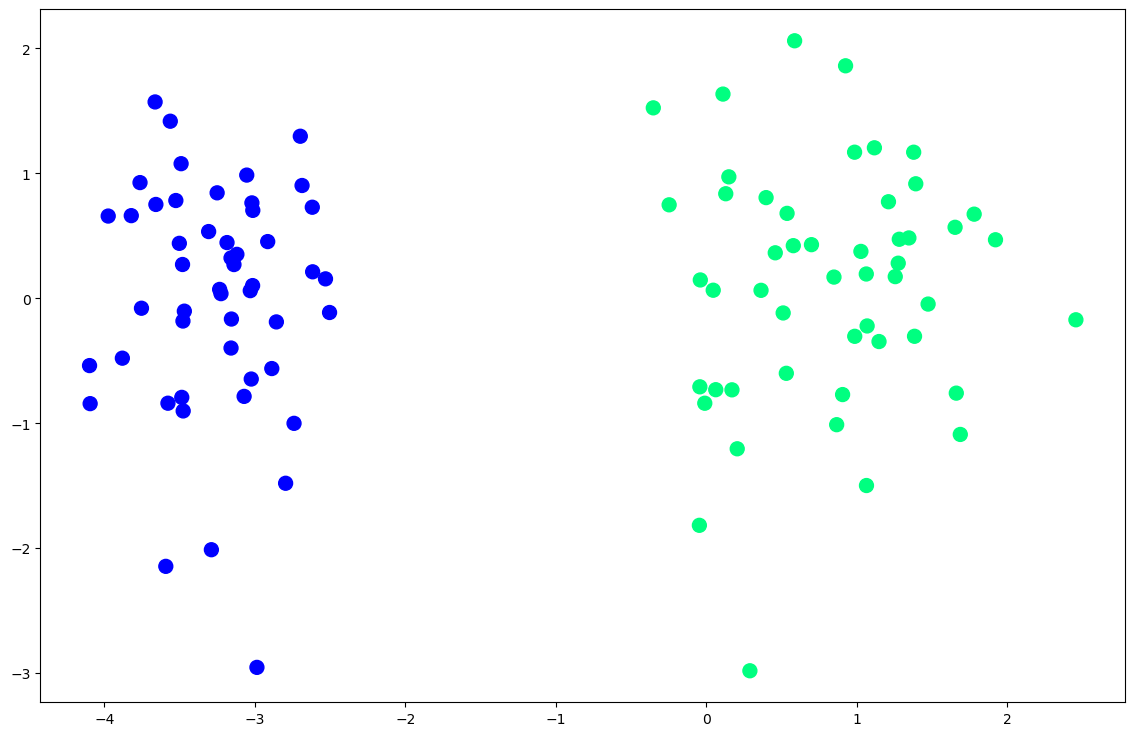

In [117]:
plt.figure(figsize=(14,9))
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)
plt.show()

In [118]:
from sklearn.linear_model import LogisticRegression
lor=LogisticRegression(penalty=None,solver='sag')
lor.fit(x,y)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [119]:
m= - (lor.coef_[0][0] / lor.coef_[0][1])
b= -(lor.intercept_ / lor.coef_[0][1])

In [120]:
x_input=np.linspace(-3,3,100)
y_input=m * x_input + b

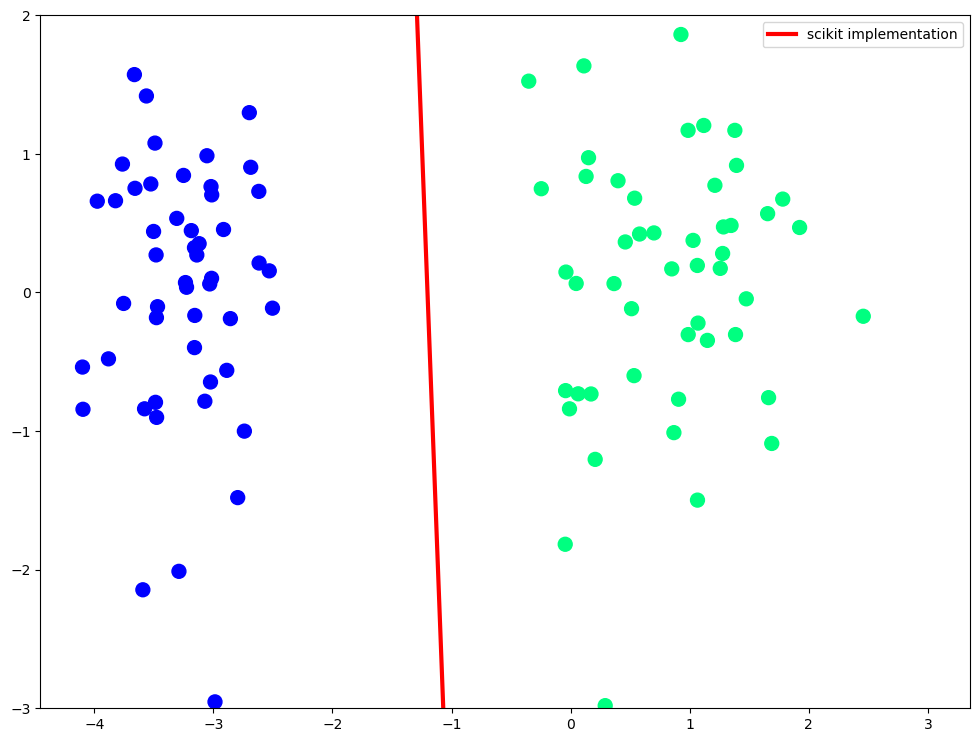

In [121]:
plt.figure(figsize=(12,9))
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)
plt.plot(x_input,y_input,color='red',linewidth=3,label='scikit implementation')
plt.ylim(-3,2)
plt.legend()
plt.show()


In [122]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [137]:
def GradienDescentInLR(x,y):
    x=np.insert(x,0,1,axis=1)
    weights=np.ones(x.shape[1])
    lr=0.5
    #batch gradient descent
    for i in range(3000):
        y_hat=sigmoid(np.dot(x,weights)) 
        weights=weights+(lr*(np.dot((y-y_hat),x)))/x.shape[0]
    return weights[0],weights[1:]

In [138]:
intercept,coef=GradienDescentInLR(x,y)

In [139]:
print(intercept)

5.326795923389574


In [140]:
print(coef)

[4.48732321 0.18187793]


In [141]:
m= -(coef[0]/coef[1])
b=-(intercept/coef[1])

In [142]:
x_input1=np.linspace(-3,3,100)
y_input1=m*x_input1+b

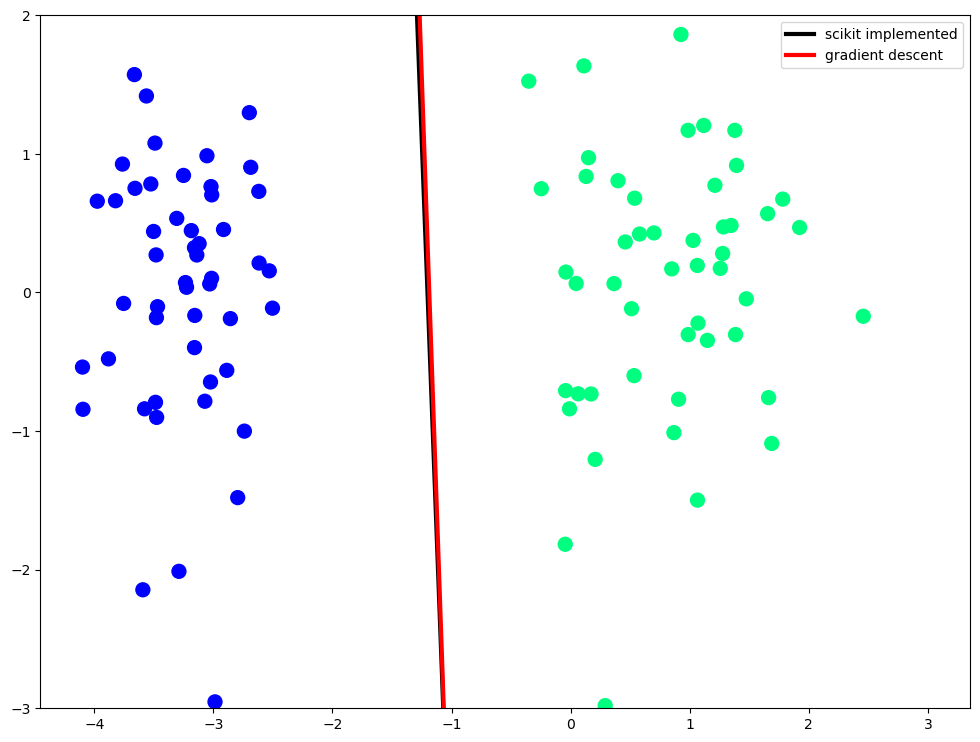

In [143]:
plt.figure(figsize=(12,9))
plt.plot(x_input,y_input,color='black',linewidth=3,label='scikit implemented')
plt.plot(x_input1,y_input1,color='red',linewidth=3,label='gradient descent')
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
plt.legend()
plt.show()
